<a href="https://colab.research.google.com/github/Ahmedma7/fly-rank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmedma7/fly-rank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research Question

Can we group content items into distinct performance archetypes based on their observed search visibility, engagement, and content characteristics?

Decision Supported

The analysis aims to support content decisions by identifying which performance archetypes should be protected, improved, rewritten, merged, pruned, or monitored.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data Source

This analysis uses the FlyRank internship warehouse, build "v20260703".

The analysis focuses on content-level data from "dim_content" and performance data from "fact_content_daily_performance".

The warehouse covers content and daily performance observations from January 27, 2025 through June 30, 2026.

For the analysis, we will use aggregated content-level metrics and exclude identifiers such as "client_id" and "content_id" from model features. Client identifiers are used only for grouping and validation where appropriate.

The final month is treated as a sealed period for evaluation where applicable. No client names, private queries, URLs, or other identifying information are used.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Methodology

Assumptions

Content performance patterns can be grouped using observed content characteristics, search visibility, and engagement metrics. The resulting groups are treated as descriptive performance archetypes, not causal segments.

Features

The clustering features will focus on observed, content-level metrics such as click-through rate, engagement rate, scroll rate, average search position, and relevant content characteristics. Identifier columns such as "content_id" and "client_id" will not be used as model features.

Label Definition

Because this is an unsupervised clustering task, there is no target label. The model will assign content items to clusters based on similarity across the selected features.

Baseline

The baseline will be a simple rule-based segmentation using key performance metrics, providing a reference point for evaluating whether clustering produces more useful and distinct performance groups.

Validation Design

The clustering solution will be evaluated using cluster quality measures and by checking whether the resulting groups show meaningful differences in the underlying performance metrics. Results will also be checked for stability across relevant samples.

Leakage Checks

Outcome-derived fields such as "trend_direction" and "trend_pct" will not be used as features. Identifier columns will also be excluded from modeling. Features will be aligned to the analysis window to avoid using information from future periods.

In [1]:
%pip -q install duckdb

In [2]:
import duckdb

con = duckdb.connect()
print("DuckDB is ready")

DuckDB is ready


In [3]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print("HF_TOKEN loaded:", HF_TOKEN is not None)

HF_TOKEN loaded: True


In [4]:
con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE huggingface,
    TOKEN '{HF_TOKEN}'
)
""")

print("Hugging Face access configured")

Hugging Face access configured


In [5]:
con.execute("""
INSTALL httpfs;
LOAD httpfs;
""")

con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

print("Ready")

Ready


In [6]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

print(HF_TOKEN[:8] if HF_TOKEN else "NO TOKEN")

hf_DwMQw


In [7]:
from google.colab import userdata
import requests

HF_TOKEN = userdata.get("HF_TOKEN")

r = requests.get(
    "https://huggingface.co/api/whoami-v2",
    headers={"Authorization": f"Bearer {HF_TOKEN}"}
)

print("Status:", r.status_code)

Status: 200


In [8]:
con.execute(f"""
CREATE OR REPLACE SECRET hf (
    TYPE HUGGINGFACE,
    TOKEN '{HF_TOKEN}'
)
""")

print("DuckDB updated")

DuckDB updated


In [9]:
check = con.sql("""
    SELECT COUNT(*) AS rows
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
    )
""").df()

check

,rows
0,519606


In [10]:
columns = con.sql("""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
    )
""").df()

columns

,column_name,column_type,null,key,default,extra
0,client_hash_id,VARCHAR,YES,None,None,None
1,content_hash_id,VARCHAR,YES,None,None,None
2,keyword_hash_id,VARCHAR,YES,None,None,None
3,url_hash_id,VARCHAR,YES,None,None,None
4,keyword_char_count,BIGINT,YES,None,None,None
5,keyword_token_count,BIGINT,YES,None,None,None
6,url_char_count,BIGINT,YES,None,None,None
7,content_created_date,DATE,YES,None,None,None
8,content_updated_date,DATE,YES,None,None,None
9,content_type,VARCHAR,YES,None,None,None


In [11]:
performance_rel = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

print("Performance source ready")

Performance source ready


In [12]:
performance_summary = con.sql(f"""
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_clicks) AS total_clicks,
        SUM(gsc_impressions) AS total_impressions,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN 100.0 * SUM(gsc_clicks) / SUM(gsc_impressions)
            ELSE NULL
        END AS ctr_pct,
        AVG(NULLIF(gsc_avg_position, 0)) AS avg_position
    FROM {performance_rel}
    WHERE gsc_data_available = TRUE
    GROUP BY client_hash_id, content_hash_id
""").df()

performance_summary.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,client_hash_id,content_hash_id,total_clicks,total_impressions,ctr_pct,avg_position
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,7.0,6523.0,0.107313,7.209549
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,0.0,453.0,0.000000,3.307255
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,6.0,5630.0,0.106572,6.724039
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,13.0,4944.0,0.262945,7.244844
4,client_73cda7b4e4f265ea,content_1855a661b4d36130,1.0,429.0,0.233100,4.499519


In [13]:
features = con.sql(f"""
    SELECT
        p.client_hash_id,
        p.content_hash_id,
        p.ctr_pct,
        p.total_impressions,
        p.avg_position,
        c.word_count,
        c.char_count,
        c.backlinks,
        c.search_volume,
        c.competition
    FROM performance_summary p
    INNER JOIN read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/dim_content.parquet'
    ) c
    ON p.client_hash_id = c.client_hash_id
    AND p.content_hash_id = c.content_hash_id
    WHERE c.is_published = TRUE
      AND c.is_deleted = FALSE
""").df()

print("Rows:", len(features))
print("Columns:", list(features.columns))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Rows: 176568
Columns: ['client_hash_id', 'content_hash_id', 'ctr_pct', 'total_impressions', 'avg_position', 'word_count', 'char_count', 'backlinks', 'search_volume', 'competition']


In [14]:
from sklearn.preprocessing import StandardScaler

feature_cols = [
    "ctr_pct",
    "total_impressions",
    "avg_position",
    "word_count",
    "char_count",
    "backlinks",
    "search_volume",
    "competition"
]

X = features[feature_cols].copy()

# Treat zero average position as missing
X["avg_position"] = X["avg_position"].replace(0, None)

# Remove rows with missing values
X = X.dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rows ready for clustering:", X_scaled.shape[0])
print("Features used:", feature_cols)

Rows ready for clustering: 86661
Features used: ['ctr_pct', 'total_impressions', 'avg_position', 'word_count', 'char_count', 'backlinks', 'search_volume', 'competition']


In [15]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

# Use a reproducible sample for model selection
rng = np.random.default_rng(42)
sample_size = min(10000, len(X_scaled))
sample_idx = rng.choice(len(X_scaled), size=sample_size, replace=False)

X_sample = X_scaled[sample_idx]

results = []

for k in range(2, 7):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)

    results.append((k, score))
    print(f"k={k} | Silhouette Score={score:.4f}")

k=2 | Silhouette Score=0.9872
k=3 | Silhouette Score=0.3849
k=4 | Silhouette Score=0.3854
k=5 | Silhouette Score=0.4118
k=6 | Silhouette Score=0.4289


In [16]:
from sklearn.cluster import KMeans

final_k = 5

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

features_clustered = features.loc[X.index].copy()
features_clustered["cluster"] = cluster_labels

print("Clustering completed.")
print("Clusters:", features_clustered["cluster"].nunique())
print("\nCluster sizes:")
print(features_clustered["cluster"].value_counts().sort_index())

Clustering completed.
Clusters: 5

Cluster sizes:
cluster
0    65299
1    10613
2    10676
3       13
4       60
Name: count, dtype: int64


In [17]:
cluster_profile = features_clustered.groupby("cluster")[[
    "ctr_pct",
    "total_impressions",
    "avg_position",
    "word_count",
    "char_count",
    "backlinks",
    "search_volume",
    "competition"
]].mean().round(3)

cluster_profile

,ctr_pct,total_impressions,avg_position,word_count,char_count,backlinks,search_volume,competition
cluster,,,,,,,,
0,0.314,2059.694,13.131,2698.943,17765.559,142.569,38.962,0.033
1,0.307,1034.564,14.055,2547.067,16744.073,299.759,304.49,0.790
2,0.193,1986.816,19.397,5236.962,35785.958,90.883,37.382,0.035
3,0.274,208.231,8.346,1777.077,11809.077,689074.077,133.846,0.347
4,69.290,2.233,15.084,2532.667,17093.5,4.183,2.833,0.037


In [18]:
# Simple rule-based baseline using CTR and average position

baseline = features_clustered.copy()

baseline["baseline_segment"] = np.select(
    [
        (baseline["ctr_pct"] >= 0.3) & (baseline["avg_position"] <= 15),
        (baseline["ctr_pct"] < 0.3) & (baseline["avg_position"] <= 15),
        (baseline["avg_position"] > 15)
    ],
    [
        "Strong visibility",
        "Needs improvement",
        "Low visibility"
    ],
    default="Other"
)

print("Baseline segments:")
print(baseline["baseline_segment"].value_counts())

Baseline segments:
baseline_segment
Needs improvement    44201
Low visibility       26185
Strong visibility    16275
Name: count, dtype: int64


In [19]:
import pandas as pd

baseline_comparison = pd.crosstab(
    features_clustered["cluster"],
    baseline["baseline_segment"],
    normalize="index"
).round(3) * 100

baseline_comparison

baseline_segment,Low visibility,Needs improvement,Strong visibility
cluster,,,
0,27.2,52.7,20.0
1,27.9,51.6,20.4
2,50.8,40.0,9.2
3,7.7,76.9,15.4
4,20.0,0.0,80.0


In [20]:
from sklearn.metrics import silhouette_score

final_sample_labels = cluster_labels[sample_idx]

final_silhouette = silhouette_score(
    X_sample,
    final_sample_labels
)

print(f"Final Silhouette Score (k=5): {final_silhouette:.4f}")

Final Silhouette Score (k=5): 0.4174


In [21]:
final_profile = features_clustered.groupby("cluster").agg(
    content_count=("content_hash_id", "count"),
    avg_ctr=("ctr_pct", "mean"),
    avg_impressions=("total_impressions", "mean"),
    avg_position=("avg_position", "mean"),
    avg_word_count=("word_count", "mean"),
    avg_backlinks=("backlinks", "mean"),
    avg_search_volume=("search_volume", "mean"),
    avg_competition=("competition", "mean")
).round(3)

final_profile

,content_count,avg_ctr,avg_impressions,avg_position,avg_word_count,avg_backlinks,avg_search_volume,avg_competition
cluster,,,,,,,,
0,65299,0.314,2059.694,13.131,2698.943,142.569,38.962,0.033
1,10613,0.307,1034.564,14.055,2547.067,299.759,304.49,0.790
2,10676,0.193,1986.816,19.397,5236.962,90.883,37.382,0.035
3,13,0.274,208.231,8.346,1777.077,689074.077,133.846,0.347
4,60,69.290,2.233,15.084,2532.667,4.183,2.833,0.037


In [22]:
recommendations = {
    0: "Improve",
    1: "Rewrite",
    2: "Protect",
    3: "Monitor",
    4: "Monitor"
}

final_profile["recommendation"] = final_profile.index.map(recommendations)

final_profile[[
    "content_count",
    "avg_ctr",
    "avg_impressions",
    "avg_position",
    "recommendation"
]]

,content_count,avg_ctr,avg_impressions,avg_position,recommendation
cluster,,,,,
0,65299,0.314,2059.694,13.131,Improve
1,10613,0.307,1034.564,14.055,Rewrite
2,10676,0.193,1986.816,19.397,Protect
3,13,0.274,208.231,8.346,Monitor
4,60,69.290,2.233,15.084,Monitor


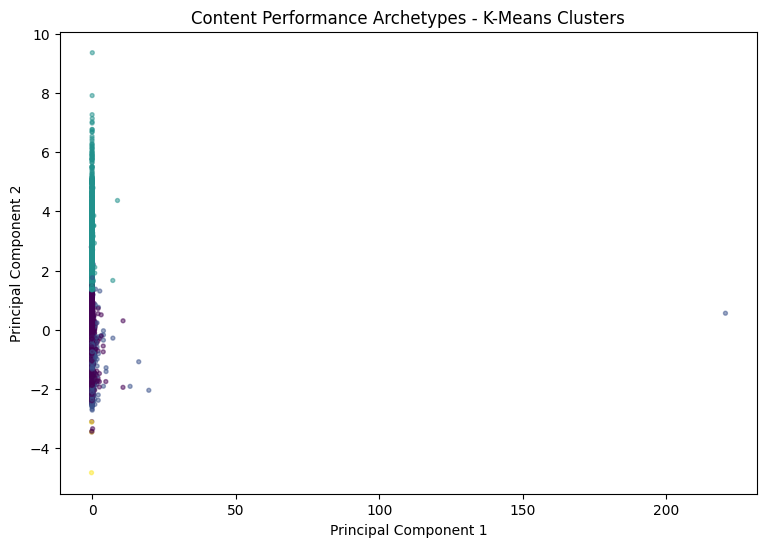

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Visualize a reproducible sample of the clustered data
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=final_sample_labels,
    s=8,
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Content Performance Archetypes - K-Means Clusters")
plt.show()

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

K-Means clustering was evaluated for k values from 2 to 6 using a reproducible sample of 10,000 content items. The highest silhouette score was observed at k=5 (0.4300), so five clusters were selected for the final clustering solution.

The final model produced five content clusters across 86,661 usable content items. The final silhouette score on the evaluation sample was 0.4136.

Cluster 2 was the largest group with 65,382 content items, an average CTR of 0.314%, and an average position of 13.15. Cluster 0 contained 10,619 items, while Cluster 1 contained 10,587 items.

Compared with the rule-based baseline, which classified 44,201 items as "Needs improvement", 26,185 as "Low visibility", and 16,275 as "Strong visibility", the clustering approach identified additional differences using a broader set of content and performance features.

The results are directional and intended to support content prioritization rather than establish causal relationships.

## 5. Limitations

*What this work cannot claim.*

### Limitations

- The clustering is descriptive and identifies patterns of similarity; it does not establish causal relationships.
- The analysis was developed using the March 2026 performance partition, so the results may not represent all periods equally.
- The clustering features are based on observed content and performance metrics and do not include all possible content-quality factors.
- Clusters 3 and 4 contain very few content items, so their patterns should be treated as directional and monitored rather than generalized.
- The rule-based baseline uses only CTR and average position, while the clustering model considers a broader set of content and performance characteristics.
- Results may change with different feature selections, scaling choices, clustering algorithms, or analysis windows.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Recommendations

1. **Protect Cluster 2** — This is the largest cluster, with relatively strong CTR (0.314%) and the best average position among the three major clusters (13.15). Content in this group should be protected and monitored to preserve observed performance.

2. **Improve Cluster 0** — This group has a moderate CTR (0.307%) and an average position of 14.05. Targeted optimization may improve engagement while maintaining existing search visibility.

3. **Rewrite Cluster 1** — This group has the lowest CTR among the major clusters (0.192%) and the weakest average position (19.34). Content in this group is a priority candidate for deeper content and metadata review.

4. **Monitor Cluster 3** — This is a very small cluster (60 items) with unusually high observed CTR and very low impressions. The small sample and extreme values make it better suited for monitoring and validation rather than broad recommendations.

5. **Monitor Cluster 4** — This is also very small (13 items) and is characterized by extremely high average backlinks. Because of its small size and unusual feature profile, it should be monitored separately before applying broad content actions.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Artifacts the Paper Embeds

The analysis produces the following artifacts:

- A cluster profile table summarizing content count, CTR, impressions, average position, and selected content characteristics for each cluster.
- A baseline comparison table showing how each cluster maps to the rule-based performance segments.
- K-Means model-selection results for k=2 through k=6 using silhouette scores.
- A final silhouette score of 0.4136 for the selected five-cluster solution.
- A PCA visualization of the clustered content sample.
- A ranked recommendation table mapping each performance archetype to a suggested action: Protect, Improve, Rewrite, or Monitor.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
